# Experimento de 140 combinaciones, parte 4: comparación de optimizadores

La guía pide demostrar con números si la optimización bayesiana y el algoritmo genético son más eficientes que el grid search y el random search. Con el mismo
presupuesto (30 evaluaciones por búsqueda), los mismos pliegues internos y un solo hilo por modelo, se compara la métrica externa a la que
llegan, el tiempo total y por evaluación, qué tan rápido llegan a su mejor valor (curvas de desempeño anytime), la calidad por
unidad de presupuesto con una prueba pareada entre combinaciones y la estabilidad ante la semilla.

En las tablas y las gráficas los cuatro aparecen como `grilla` (grid search), `aleatoria` (random search), `bayesiana` (Optuna) y `genetica` (DEAP).

Al final va el successive halving (multifidelidad), corrido aparte y sin balanceo.

## Flujo del experimento

![Flujo del experimento](fig_pipeline_experimento.png)

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st
from src import analisis, config, runner, stats

OPT = ["grilla", "aleatoria", "bayesiana", "genetica"]
COLOR = {"grilla": "#7F7F7F", "aleatoria": "#1A1A1A", "bayesiana": "#C0141F", "genetica": "#E8898F", "halving": "#4C72B0"}
maestra, res = analisis.cargar()
trazas = pd.read_parquet(config.TRAZAS)
trazas = trazas[trazas.optimizador.isin(OPT)]
if "fraccion" not in trazas:
    trazas["fraccion"] = 1.0
trazas["fraccion"] = trazas["fraccion"].fillna(1.0)
combos = res[["tarea", "modelo", "balanceo"]].drop_duplicates()
completas = res.groupby(["tarea", "modelo", "balanceo"]).optimizador.nunique()
completas = completas[completas == 4].index
res4 = res.set_index(["tarea", "modelo", "balanceo"]).loc[completas].reset_index()
print(f"Grupos (tarea, modelo, balanceo) con los 4 optimizadores completos: {len(completas)}")

Grupos (tarea, modelo, balanceo) con los 4 optimizadores completos: 34


C:\Users\Enma\miniconda3\envs\solarpv-eda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Métrica externa por optimizador

Para cada grupo (tarea, modelo, balanceo) se ordenan los cuatro optimizadores por su métrica externa (F1 macro en clasificación, R² en
regresión). Rango 1 es el mejor.

In [2]:
res4["externa"] = np.where(res4.tarea == "clf", res4.f1_macro, res4.r2)
res4["rango"] = res4.groupby(["tarea", "modelo", "balanceo"]).externa.rank(ascending=False)
ganador = res4.loc[res4.groupby(["tarea", "modelo", "balanceo"]).externa.idxmax()]
tabla = pd.DataFrame({
    "rango medio": res4.groupby("optimizador").rango.mean(),
    "veces mejor": ganador.optimizador.value_counts(),
    "métrica externa media": res4.groupby("optimizador").externa.mean(),
}).reindex(OPT).fillna(0)
piv_ext = res4.pivot_table(index=["tarea", "modelo", "balanceo"], columns="optimizador", values="externa")[OPT]
tabla["diferencia media con la grilla"] = piv_ext.sub(piv_ext["grilla"], axis=0).mean()
tabla.round(4)

,rango medio,veces mejor,métrica externa media,diferencia media con la grilla
optimizador,,,,
grilla,2.6912,3,0.7505,0.0000
aleatoria,2.1324,14,0.7527,0.0022
bayesiana,2.1471,12,0.7533,0.0027
genetica,3.0294,5,0.7487,-0.0018


In [3]:
piv = res4.pivot_table(index=["tarea", "modelo", "balanceo"], columns="optimizador", values="externa")[OPT]
filas = []
for a in OPT:
    for c in OPT:
        if a < c:
            w = st.wilcoxon(piv[a], piv[c], zero_method="zsplit")
            filas.append({"comparación": f"{a} vs {c}", "mediana de la diferencia": float(np.median(piv[a] - piv[c])),
                          "p Wilcoxon": w.pvalue, "delta de Cliff": stats.cliff_delta(piv[a], piv[c])["delta"]})
w = pd.DataFrame(filas)
w["p Holm"] = stats.holm(w["p Wilcoxon"])
w.set_index("comparación").round(4)

,mediana de la diferencia,p Wilcoxon,delta de Cliff,p Holm
comparación,,,,
aleatoria vs grilla,0.0005,0.0064,0.0458,0.0256
aleatoria vs bayesiana,-0.0000,0.4266,-0.0078,0.4266
aleatoria vs genetica,0.0018,0.0002,0.0718,0.0014
bayesiana vs grilla,0.0004,0.0141,0.0407,0.0424
bayesiana vs genetica,0.0011,0.0006,0.0709,0.0032
genetica vs grilla,-0.0001,0.1346,-0.0337,0.2693


Prueba de rangos con signo de Wilcoxon, pareada por grupo (Wilcoxon, 1945), con p ajustado por Holm. La delta de Cliff dice qué tan seguido un
optimizador queda por encima del otro, sin depender de la escala de la métrica.

## 2. Tiempo y evaluaciones

El tiempo por evaluación depende sobre todo del modelo y de los hiperparámetros que el optimizador decide probar (más árboles, más vecinos,
C más grande), no del optimizador en sí. El costo propio de TPE y del algoritmo genético es despreciable frente a entrenar un modelo.

In [4]:
t = res4.groupby("optimizador")[["evaluaciones", "t_busqueda", "t_por_evaluacion"]].agg(["mean", "sum"])
t.columns = [f"{a} ({'media' if b == 'mean' else 'total'})" for a, b in t.columns]
t = t[["evaluaciones (media)", "t_busqueda (media)", "t_busqueda (total)", "t_por_evaluacion (media)"]]
t["horas-núcleo de búsqueda"] = t["t_busqueda (total)"] * config.K_EXTERNO / 3600 / config.K_EXTERNO
t.reindex(OPT).round(2)

,evaluaciones (media),t_busqueda (media),t_busqueda (total),t_por_evaluacion (media),horas-núcleo de búsqueda
optimizador,,,,,
grilla,26.79,509.17,17311.88,20.14,4.81
aleatoria,30.00,595.47,20245.88,19.85,5.62
bayesiana,29.62,826.68,28107.15,27.79,7.81
genetica,28.44,583.03,19823.18,20.17,5.51


In [5]:
por_modelo = res4.pivot_table(index=["tarea", "modelo"], columns="optimizador", values="t_busqueda", aggfunc="mean")[OPT]
por_modelo.round(1)

optimizador                grilla  aleatoria  bayesiana  genetica
tarea modelo                                                     
clf   KNN                   394.3      449.3      366.5     218.1
      Naive Bayes           160.6      161.3      163.1      90.8
      Random Forest        1955.0     2468.4     4072.6    2646.1
      Regresión logística   210.9      222.9      203.3     167.8
      SVM RBF               456.0      471.6      404.2     361.4
      XGBoost               526.8      563.9      713.5     698.9
      Árbol de decisión     157.8      199.1      216.6     209.4
reg   KNN                   172.8      199.9      194.5     137.6
      Lasso                  11.3       12.0       12.4      12.3
      Random Forest         927.7     1185.6     2491.5    1555.7
      Ridge                  11.8       12.1       11.8      11.7
      SVR RBF               935.7      957.0     1040.9     554.9
      XGBoost               178.1      151.8      125.3     168.0
      Árbol de decisión      22.8       30.8       38.4      31.0

## 3. Curvas de desempeño anytime

Para cada búsqueda (grupo y pliegue externo) se toma el mejor puntaje interno visto hasta la evaluación t. Para poder promediar entre modelos
con escalas distintas, se normaliza como *regret* (cuánto falta para el mejor valor): 0 es el mejor valor que encontró cualquiera de los cuatro optimizadores en esa búsqueda y 1
es la mediana de todas sus evaluaciones; se acota en 1 (un mejor valor por debajo de la mediana cuenta como 1, para que un primer candidato desastroso no domine el promedio). Menor es mejor.

El grid search evalúa en orden lexicográfico, así que su curva depende de ese orden: es la curva de quien la recorre de principio a fin.

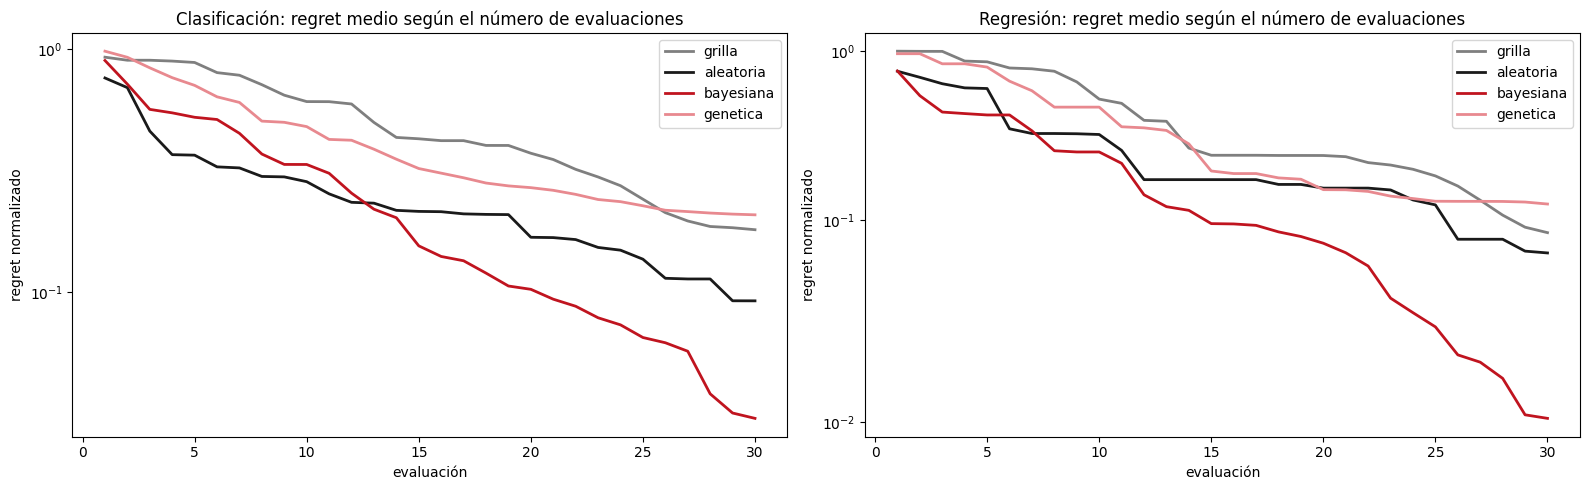

In [6]:
tz = trazas[trazas.fraccion == 1.0].copy()
tz = tz[np.isfinite(tz.puntaje)]
claves = ["tarea", "modelo", "balanceo", "pliegue"]
tz = tz.merge(pd.DataFrame(list(completas), columns=["tarea", "modelo", "balanceo"]), on=["tarea", "modelo", "balanceo"])
tz = tz.sort_values(claves + ["optimizador", "evaluacion"])
tz["mejor_hasta"] = tz.groupby(claves + ["optimizador"]).puntaje.cummax()
tz["t_acumulado"] = tz.groupby(claves + ["optimizador"]).segundos.cumsum()
ref = tz.groupby(claves).puntaje.agg(maximo="max", mediana="median")
tz = tz.join(ref, on=claves)
tz["regret"] = ((tz.maximo - tz.mejor_hasta) / (tz.maximo - tz.mediana).replace(0, np.nan)).clip(0, 1)

def curva(df):
    # cada búsqueda se extiende hasta 30 con su último valor, para que la grilla (24 o 27 evaluaciones) no salga de la cuenta
    filas = []
    for _, g in df.groupby(claves + ["optimizador"]):
        r = g.set_index("evaluacion").regret.reindex(range(1, config.PRESUPUESTO + 1)).ffill()
        filas.append(r.rename(g.optimizador.iloc[0]))
    return pd.concat(filas, axis=1).T.groupby(level=0).mean().T

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, tarea, titulo in zip(axes, ["clf", "reg"], ["Clasificación", "Regresión"]):
    sub = tz[tz.tarea == tarea]
    if sub.empty:
        ax.axis("off"); continue
    c = curva(sub)
    for o in OPT:
        if o in c:
            ax.plot(c.index, c[o], label=o, color=COLOR[o], lw=2)
    ax.set_title(f"{titulo}: regret medio según el número de evaluaciones"); ax.set_xlabel("evaluación"); ax.set_ylabel("regret normalizado")
    ax.set_yscale("symlog", linthresh=0.05); ax.legend()
fig.tight_layout(); fig.savefig("fig_exp_anytime.png", dpi=130, bbox_inches="tight"); plt.show()

## 4. Calidad por unidad de presupuesto

Tres medidas por búsqueda, promediadas:

- Área bajo la curva de regret (de la evaluación 1 a la 30, dividida por 30): resume toda la curva; menor es mejor.
- Evaluaciones hasta el 95 %: cuántas evaluaciones tarda en cerrar el 95 % de la distancia entre la mediana y el mejor valor de esa búsqueda.
- Mejor valor final (regret en la evaluación 30).

La prueba pareada (Wilcoxon por búsqueda, con Holm) dice si las diferencias entre optimizadores son sistemáticas o ruido.

In [7]:
filas = []
for k, g in tz.groupby(claves + ["optimizador"]):
    r = g.set_index("evaluacion").regret.reindex(range(1, config.PRESUPUESTO + 1)).ffill().bfill()
    llega = r[r <= 0.05]
    filas.append({**dict(zip(claves + ["optimizador"], k)), "area_regret": r.mean(), "regret_final": r.iloc[-1],
                  "evals_hasta_95": llega.index.min() if len(llega) else np.nan, "segundos": g.segundos.sum()})
ef = pd.DataFrame(filas)
display(ef.groupby("optimizador")[["area_regret", "regret_final", "evals_hasta_95", "segundos"]].mean().reindex(OPT).round(3))

piv = ef.pivot_table(index=claves, columns="optimizador", values="area_regret")[OPT].dropna()
filas = []
for a, c in [("bayesiana", "grilla"), ("bayesiana", "aleatoria"), ("genetica", "grilla"), ("genetica", "aleatoria"),
             ("aleatoria", "grilla"), ("bayesiana", "genetica")]:
    w = st.wilcoxon(piv[a], piv[c], zero_method="zsplit")
    filas.append({"comparación": f"{a} vs {c}", "búsquedas": len(piv), "el primero mejor (%)": 100 * np.mean(piv[a] < piv[c]),
                  "mediana de la diferencia de área": float(np.median(piv[a] - piv[c])), "p": w.pvalue})
ef_t = pd.DataFrame(filas)
ef_t["p Holm"] = stats.holm(ef_t.p)
ef_t.set_index("comparación").round(4)

,area_regret,regret_final,evals_hasta_95,segundos
optimizador,,,,
grilla,0.486,0.160,16.691,509.157
aleatoria,0.256,0.086,14.500,595.449
bayesiana,0.240,0.034,16.387,826.471
genetica,0.406,0.190,14.143,583.004


,búsquedas,el primero mejor (%),mediana de la diferencia de área,p,p Holm
comparación,,,,,
bayesiana vs grilla,168,80.9524,-0.2028,0.0000,0.0000
bayesiana vs aleatoria,168,58.9286,-0.0430,0.0960,0.0960
genetica vs grilla,168,57.1429,-0.0380,0.0031,0.0062
genetica vs aleatoria,168,23.8095,0.1089,0.0000,0.0000
aleatoria vs grilla,168,72.0238,-0.2224,0.0000,0.0000
bayesiana vs genetica,168,77.3810,-0.1232,0.0000,0.0000


## 5. Diversidad del algoritmo genético

Si la diversidad cae a cero muy pronto, la población convergió prematuramente y el algoritmo genético deja de explorar. Distancia media entre individuos en
el cubo unitario (0 = todos iguales) e individuos distintos de una población de 6.

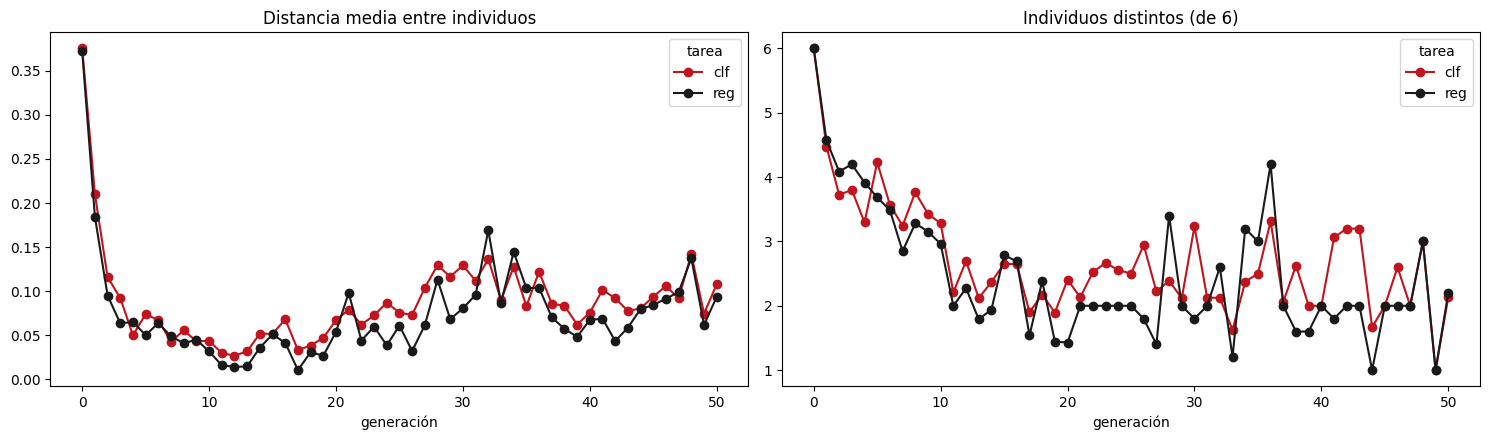

distancia_media       
                              first   last
modelo                                    
KNN                           0.361  0.112
Lasso                         0.352  0.005
Naive Bayes                   0.352  0.008
Random Forest                 0.394  0.055
Regresión logística           0.361  0.225
Ridge                         0.352  0.050
SVM RBF                       0.361  0.016
SVR RBF                       0.351  0.019
XGBoost                       0.400  0.006
Árbol de decisión             0.394  0.044

In [8]:
ruta = config.RUNS / "diversidad.parquet"
if ruta.exists():
    dv = pd.read_parquet(ruta)
    dv = dv[dv.optimizador == "genetica"]
    g = dv.groupby(["tarea", "generacion"])[["distancia_media", "distintos"]].mean().unstack("tarea")
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    g["distancia_media"].plot(ax=axes[0], marker="o", color=["#C0141F", "#1A1A1A"][:g["distancia_media"].shape[1]])
    axes[0].set_title("Distancia media entre individuos"); axes[0].set_xlabel("generación")
    g["distintos"].plot(ax=axes[1], marker="o", color=["#C0141F", "#1A1A1A"][:g["distintos"].shape[1]])
    axes[1].set_title("Individuos distintos (de 6)"); axes[1].set_xlabel("generación")
    fig.tight_layout(); fig.savefig("fig_exp_diversidad.png", dpi=130, bbox_inches="tight"); plt.show()
    display(dv.groupby("modelo")[["distancia_media"]].agg(["first", "last"]).round(3))

## 6. Successive halving (multifidelidad)

Corrido sin balanceo para los 14 modelos. Mira 90 candidatos con 1/9 de los datos, 30 con 1/3 y 10 con todos, por el mismo costo que 30
evaluaciones completas. Se compara contra los otros cuatro en las mismas combinaciones.

In [9]:
m_all, r_all = analisis.cargar(incluir_halving=True)
hv = r_all[(r_all.balanceo.isin(["ninguno", runner.SIN_BALANCEO]))]
if "halving" in set(hv.optimizador):
    hv = hv.assign(externa=np.where(hv.tarea == "clf", hv.f1_macro, hv.r2))
    comp = hv.pivot_table(index=["tarea", "modelo"], columns="optimizador", values="externa")
    display(comp[[c for c in OPT + ["halving"] if c in comp]].round(4))
    tiempo = hv.pivot_table(index=["tarea", "modelo"], columns="optimizador", values="t_busqueda")
    display(tiempo[[c for c in OPT + ["halving"] if c in tiempo]].round(1))
else:
    print("El halving todavía no termina.")

optimizador                grilla  aleatoria  bayesiana  genetica  halving
tarea modelo                                                              
clf   KNN                  0.7973     0.7992     0.7993    0.7993   0.7988
      Naive Bayes          0.5749     0.5759     0.5803    0.5799   0.5759
      Random Forest        0.8935     0.8944     0.8927    0.8927   0.8916
      Regresión logística  0.6003     0.6003     0.6003    0.6003   0.6003
      SVM RBF              0.8130     0.8150     0.8134    0.8144   0.8135
      XGBoost              0.8825     0.8882     0.8881    0.8808   0.8889
      Árbol de decisión    0.8684     0.8804     0.8814    0.8752   0.8798
reg   KNN                  0.7988     0.7994     0.7984    0.7963   0.7982
      Lasso                0.4791     0.4791     0.4791    0.4791   0.4793
      Random Forest        0.9023     0.9025     0.9023    0.9026   0.9024
      Ridge                0.4795     0.4795     0.4794    0.4794   0.4791
      SVR RBF              0.7857     0.7850     0.7921    0.7764   0.7850
      XGBoost              0.8905     0.8948     0.8989    0.8903   0.8951
      Árbol de decisión    0.8791     0.8810     0.8802    0.8704   0.8816

optimizador                grilla  aleatoria  bayesiana  genetica  halving
tarea modelo                                                              
clf   KNN                   176.5      201.1      197.8     117.7    167.5
      Naive Bayes            14.3       14.4       14.4      13.1     16.4
      Random Forest         981.9     1251.4     1603.5    1092.5   1356.5
      Regresión logística    96.1      100.6      101.6      89.4    186.4
      SVM RBF               356.0      371.6      293.8     232.5   1332.0
      XGBoost               319.7      343.3      317.5     438.6    447.7
      Árbol de decisión      24.1       30.7       37.5      29.2     37.2
reg   KNN                   172.8      199.9      194.5     137.6    182.0
      Lasso                  11.3       12.0       12.4      12.3     10.7
      Random Forest         927.7     1185.6     2491.5    1555.7   1362.9
      Ridge                  11.8       12.1       11.8      11.7     11.0
      SVR RBF               935.7      957.0     1040.9     554.9   3867.1
      XGBoost               178.1      151.8      125.3     168.0    307.8
      Árbol de decisión      22.8       30.8       38.4      31.0     35.2

## 7. Estabilidad ante la semilla

La semilla cambia los pliegues, los candidatos aleatorios, el muestreador de TPE, la población inicial del algoritmo genético y la aleatoriedad de los
modelos. Se repite un subconjunto (Random Forest, XGBoost y SVM, sin balanceo, con los cuatro optimizadores) con otras semillas y se mira
cuánto cambia la métrica externa.

In [10]:
partes = runner.tabla_partes()
partes = partes[partes.optimizador.isin(OPT)]
sem = partes.groupby(["tarea", "modelo", "balanceo", "optimizador", "semilla"]).agg(
    externa=("f1_macro", "mean"), r2=("r2", "mean") if "r2" in partes else ("f1_macro", "mean"), pliegues=("pliegue", "nunique")).reset_index()
sem = sem[sem.pliegues == config.K_EXTERNO]
sem["externa"] = np.where(sem.tarea == "clf", sem.externa, sem.r2)
varias = sem.groupby(["tarea", "modelo", "balanceo", "optimizador"]).semilla.nunique()
varias = varias[varias > 1].index
if len(varias):
    s = sem.set_index(["tarea", "modelo", "balanceo", "optimizador"]).loc[varias].reset_index()
    out = s.groupby(["tarea", "modelo", "optimizador"]).externa.agg(["mean", "std", "min", "max", "count"])
    display(out.round(4))
else:
    print("Las corridas con otras semillas todavía no terminan.")

mean     std     min     max  count
tarea modelo        optimizador                                       
clf   Random Forest aleatoria    0.8926  0.0025  0.8908  0.8944      2
                    bayesiana    0.8923  0.0006  0.8918  0.8927      2
                    genetica     0.8926  0.0000  0.8926  0.8927      2
                    grilla       0.8924  0.0015  0.8914  0.8935      2
      SVM RBF       aleatoria    0.8163  0.0017  0.8150  0.8175      2
                    bayesiana    0.8162  0.0039  0.8134  0.8189      2
                    genetica     0.8154  0.0014  0.8144  0.8164      2
                    grilla       0.8153  0.0033  0.8130  0.8177      2
      XGBoost       aleatoria    0.8866  0.0022  0.8851  0.8882      2
                    bayesiana    0.8882  0.0001  0.8881  0.8883      2
                    genetica     0.8812  0.0005  0.8808  0.8815      2
                    grilla       0.8836  0.0014  0.8825  0.8846      2

## 8. Interpretación

Con 30 evaluaciones las diferencias entre optimizadores son pequeñas. La métrica externa media va de 0.7487 (algoritmo genético) a 0.7533 (optimización bayesiana), y en los 34 grupos el random search fue el mejor 14 veces y la bayesiana 12, contra 5 de la genética y 3 del grid search. Según Wilcoxon con Holm, el random search y la bayesiana superan al grid search (p de 0.026 y 0.042) y a la genética (p de 0.001 y 0.003), no se distinguen entre sí (p = 0.43), y la genética no se distingue del grid search. Los deltas de Cliff son menores que 0.08, es decir, efectos despreciables.

Por unidad de presupuesto la bayesiana es la mejor: tiene el menor área bajo la curva de regret (0.240, frente a 0.256 del random search, 0.406 de la genética y 0.486 del grid search) y el menor regret final (0.034). Gana al grid search en el 81 % de las búsquedas y a la genética en el 77 %, pero frente al random search la diferencia no es significativa (p = 0.096). Ningún optimizador llega mucho antes al 95 % de la distancia: van de 14.1 evaluaciones (genética) a 16.7 (grid search). La bayesiana además cuesta más por evaluación, 27.8 s contra unos 20 s de las demás, y la diferencia se concentra en Random Forest, donde su búsqueda tarda 4,073 s contra 1,955 s del grid search.

La genética, con población de 6, pierde diversidad pronto: la distancia media entre individuos baja de 0.35 a 0.40 a menos de 0.06 en 8 de los 10 modelos, con unas 5 generaciones. El successive halving queda a menos de 0.008 del mejor de los otros cuatro en la métrica externa de los 14 modelos, y no ahorró tiempo: tardó más que el grid search en 11 de los 14, hasta cuatro veces más en el SVR RBF (3,867 s contra 936 s). Entre semillas, la métrica externa varía menos de 0.004 en Random Forest, XGBoost y SVM RBF, aunque con solo dos semillas.

## Referencias

- Akiba, T., Sano, S., Yanase, T., Ohta, T. y Koyama, M. (2019). Optuna: A next-generation hyperparameter optimization framework. En *Proceedings of the 25th ACM SIGKDD* (pp. 2623-2631). https://doi.org/10.1145/3292500.3330701
- Bergstra, J., Bardenet, R., Bengio, Y. y Kégl, B. (2011). Algorithms for hyper-parameter optimization. *Advances in Neural Information Processing Systems, 24*.
- Bergstra, J. y Bengio, Y. (2012). Random search for hyper-parameter optimization. *Journal of Machine Learning Research, 13*, 281-305.
- Cliff, N. (1993). Dominance statistics: Ordinal analyses to answer ordinal questions. *Psychological Bulletin, 114*(3), 494-509. https://doi.org/10.1037/0033-2909.114.3.494
- Fortin, F.-A., De Rainville, F.-M., Gardner, M.-A., Parizeau, M. y Gagné, C. (2012). DEAP: Evolutionary algorithms made easy. *Journal of Machine Learning Research, 13*, 2171-2175.
- Holm, S. (1979). A simple sequentially rejective multiple test procedure. *Scandinavian Journal of Statistics, 6*(2), 65-70.
- Li, L., Jamieson, K., DeSalvo, G., Rostamizadeh, A. y Talwalkar, A. (2018). Hyperband: A novel bandit-based approach to hyperparameter optimization. *Journal of Machine Learning Research, 18*(185), 1-52.
- Wilcoxon, F. (1945). Individual comparisons by ranking methods. *Biometrics Bulletin, 1*(6), 80-83. https://doi.org/10.2307/3001968